<a href="https://colab.research.google.com/github/sikendrapurampravalika-del/CSPT_Training26/blob/main/Day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install requests beautifulsoup4 pandas -q

In [14]:
import requests

url = "http://quotes.toscrape.com"
response = requests.get(url)

print(response.status_code)
html = response.text
print(html[:300])

200
<!DOCTYPE html>
<html lang="en">
<head>
	<meta charset="UTF-8">
	<title>Quotes to Scrape</title>
    <link rel="stylesheet" href="/static/bootstrap.min.css">
    <link rel="stylesheet" href="/static/main.css">
    
    
</head>
<body>
    <div class="container">
        <div class="row header-box">



In [15]:
import requests

url = "http://quotes.toscrape.com"
response = requests.get(url)

print(response.status_code)
html = response.text
print(html)

200
<!DOCTYPE html>
<html lang="en">
<head>
	<meta charset="UTF-8">
	<title>Quotes to Scrape</title>
    <link rel="stylesheet" href="/static/bootstrap.min.css">
    <link rel="stylesheet" href="/static/main.css">
    
    
</head>
<body>
    <div class="container">
        <div class="row header-box">
            <div class="col-md-8">
                <h1>
                    <a href="/" style="text-decoration: none">Quotes to Scrape</a>
                </h1>
            </div>
            <div class="col-md-4">
                <p>
                
                    <a href="/login">Login</a>
                
                </p>
            </div>
        </div>
    

<div class="row">
    <div class="col-md-8">

    <div class="quote" itemscope itemtype="http://schema.org/CreativeWork">
        <span class="text" itemprop="text">“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”</span>
        <span>by <small class="

In [16]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "html.parser")
quotes = soup.find_all("div", class_="quote")

print(f"Found {len(quotes)} quotes on this page")

Found 10 quotes on this page


In [17]:
data = []
for q in quotes:
    text = q.find("span", class_="text").get_text()
    author = q.find("small", class_="author").get_text()
    tags = [t.get_text() for t in q.find_all("a", class_="tag")]
    data.append({"quote": text, "author": author, "tags": tags})
print(data[0])

{'quote': '“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”', 'author': 'Albert Einstein', 'tags': ['change', 'deep-thoughts', 'thinking', 'world']}


In [18]:
import pandas as pd

df = pd.DataFrame(data)
df.head()

df.to_csv("quotes.csv", index=False)

In [19]:
df.head()

,quote,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"[change, deep-thoughts, thinking, world]"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"[abilities, choices]"
2,“There are only two ways to live your life. On...,Albert Einstein,"[inspirational, life, live, miracle, miracles]"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"[aliteracy, books, classic, humor]"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"[be-yourself, inspirational]"


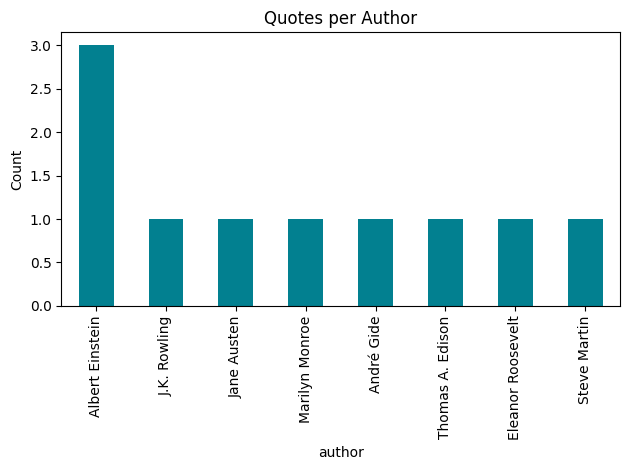

In [20]:
import matplotlib.pyplot as plt

df["author"].value_counts().plot(kind="bar", color="#028090")
plt.title("Quotes per Author")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# 1. Fetch the webpage content
url = "https://www.aceec.ac.in/academics/computer-science-and-engineering-aiml-2/"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

# 2. Parse the HTML with BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')

# 3. Find all tables on the page
tables = soup.find_all('table')
print(f"Found {len(tables)} table(s) on the page.")

# 4. Use Pandas to extract and convert the tables into DataFrames
if tables:
    # Read all tables found into a list of pandas DataFrames
    dfs = pd.read_html(str(tables))

    for index, df in enumerate(dfs):
        print(f"\n--- Table {index + 1} ---")
        print(df.head()) # Prints the first few rows of each table

        # Optional: Save individual tables to CSV files
        # df.to_csv(f'table_{index + 1}.csv', index=False)
else:
    print("No HTML <table> elements were found on this specific URL. (The layout might use CSS grids or lists instead).")

Found 13 table(s) on the page.

--- Table 1 ---
    Name of the Programme     CSE (AI & ML) CSE (AI & ML).1
0  Approved Intake (2025)               180             180
1  No. of Faculty Members                37              37
2                     NaN             Cadre          Number
3                     NaN         Professor               2
4                     NaN  Assoc. Professor               6

--- Table 2 ---
   Batch No       Internal Guide  \
0         1       Dr. S. Kavitha   
1         2  Mrs. S. Satya Sudha   
2         3        Mr. K. Kishan   
3         4     Mrs. J. Bhargavi   
4         5  Mrs. S. Satya Sudha   

                               Published Paper Title  \
0  Literature Survey on Machine Learning Approach...   
1  A Survey on Self Supervised Learning for Zero ...   
2  Orthogonal Adversarial Deep Reinforcement Lear...   
3  Navigation Tasks in Robotics using Quantum Dee...   
4  A Survey on Variational Quantum Circuits: Quan...   

                     

/tmp/ipykernel_2294/3851029786.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(str(tables))


In [22]:
dfs[0]

,Name of the Programme,CSE (AI & ML),CSE (AI & ML).1
0,Approved Intake (2025),180,180
1,No. of Faculty Members,37,37
2,NaN,Cadre,Number
3,NaN,Professor,2
4,NaN,Assoc. Professor,6
5,NaN,Asst. Professor,29
6,Faculty Profile,Qualification,No. of Faculty
7,Faculty Profile,Ph.D,7
8,Faculty Profile,Ph.D (Pursuing),13
9,Faculty Profile,M.Tech/M.E,16


In [23]:
dfs[1]

,Batch No,Internal Guide,Published Paper Title,Journal Name,DOI Number,ISSN Number
0,1,Dr. S. Kavitha,Literature Survey on Machine Learning Approach...,World Journal of Advanced Research and Reviews,10.30574/wjarr.2025.26.2.1856,eISSN: 2581-9615
1,2,Mrs. S. Satya Sudha,A Survey on Self Supervised Learning for Zero ...,International Research Journal of Modernizatio...,—,e-ISSN: 2582-5208
2,3,Mr. K. Kishan,Orthogonal Adversarial Deep Reinforcement Lear...,International Journal of Scientific Research &...,—,ISSN (Online): 2395-566X
3,4,Mrs. J. Bhargavi,Navigation Tasks in Robotics using Quantum Dee...,International Research Journal of Modernizatio...,—,e-ISSN: 2582-5208
4,5,Mrs. S. Satya Sudha,A Survey on Variational Quantum Circuits: Quan...,International Research Journal of Modernizatio...,—,e-ISSN: 2582-5208
5,6,Mrs. G. Monika,DEEPHEMOSCAN: Blood Group Prediction via Finge...,International Research Journal of Modernizatio...,—,e-ISSN: 2582-5208
6,7,Mrs. K. Swetha Sailaja,Silent Speech Recognition Using AI and ML,International Journal of Scientific Research i...,—,ISSN: 2582-3930
7,8,Mrs. P. Kamakshi Thai,Scalable Streaming Data at the Edge using Deep...,International Journal of Scientific Research i...,—,ISSN: 2582-3930
8,9,Mrs. K. Swetha Sailaja,SwitchLang AI: Advanced NLP for Seamless Code-...,International Journal of Scientific Research i...,—,ISSN: 2582-3930
9,10,Mr. C. V. Ajay Kumar,Personal Data Leakage Detection using AI,International Journal of Progressive Research ...,—,ISSN: 2583-1062


In [26]:
dfs[2]

,Batch no,Internal Guide,Published Paper Title,Journal Name,DOI Number,ISSN Number
0,1,Dr. S. Kavitha,A study on academic management systems,World Journal of Advanced Research and Reviews,https://doi.org/10.30574/wjarr.2025.26.2.1593,eISSN: 2581-9615
1,2,Dr. S. Kavitha,A Survey on Event Ease: Easy event schedule fo...,World Journal of Advanced Research and Reviews,10.30574/wjarr.2025.26.2.1601,eISSN: 2581-9615
2,3,Mr. M. Ramesh,Leveraging Real-Time Data for Stillbirth Preve...,International Journal for Research in Applied ...,10.22214/ijraset.2025.71791,ISSN: 2321-9653
3,4,Mr. Shashank Tiwari,International Research Journal of Modernizatio...,International Research Journal of Modernizatio...,no,e-ISSN: 2582-5208
4,5,Mrs. G. Monika,Flappy Bird AI using Reinforcement Learning,International Scientific Journal of Engineerin...,DOI: 10.55041/ISJEM03388,ISSN: 2583-6129
5,6,Mr. D. Ranjith,DEVELOPING AN INTELLIGENT SYSTEM FOR SUBMARINE...,International Research Journal of Modernizatio...,no,e-ISSN: 2582-5208
6,7,Mrs. J Bhargavi,A Study On Kalamitra: Empowering Artisans usin...,International Scientific Journal of Engineerin...,10.55041/ISJEM03080,ISSN: 2583-6129
7,8,Mr. C.V. Ajay Kmar,MEMORY AUGMENTED NEURAL NETWORKS FOR CONTEXTUA...,International Research Journal of Modernizatio...,no,e-ISSN: 2582-5208
8,9,Mrs. S. Satya Sudha,Ensuring Inclusivity and fairness in AI-genera...,International Journal of Innovative Research i...,IJIRT 180542,ISSN: 2349-6002
9,10,Mrs P Kamakshi Thai,Digital Signature Verification using Deep Lear...,International Journal of Scientific Research i...,10.55041/IJSREM46846,ISSN: 2582-3930
